## 1. Instalação de Dependências

# 🔬 Fine-Tuning para Detecção de Code Smells — Treino Unificado

**Modelo:** CodeBERT (`microsoft/codebert-base`)  
**Dataset:** `MergedSmells.csv` — todos os tipos de smell combinados  
**Tarefa:** Classificação Binária — *Code Smell* (1) vs *Código Normal* (0)  
**Divisão:** 80% treino / 20% teste (estratificada)

---
### 🗺️ Mapa de Experimentos
| Experimento | Modelo    | Dataset          |
|-------------|-----------|------------------|
| EXP-1       | CodeBERT  | Mixed Smells     |


In [7]:
%%capture
!pip install transformers==4.40.0 datasets scikit-learn pandas numpy matplotlib seaborn torch accelerate -q

## 2. Importações

In [8]:
import os, re, json, random, warnings, copy
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, classification_report, roc_curve,
)

# ── Detecção de GPUs ──────────────────────────────────────────
N_GPUS = torch.cuda.device_count()
print(f'✅ Imports OK')
print(f'🔥 PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()} | GPUs: {N_GPUS}')
for i in range(N_GPUS):
    print(f'   GPU {i}: {torch.cuda.get_device_name(i)}')


✅ Imports OK
🔥 PyTorch 2.10.0+cu128 | CUDA: True | GPUs: 2
   GPU 0: Tesla T4
   GPU 1: Tesla T4


## 3. Configurações Globais

In [ ]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed()

# ── Número de GPUs disponíveis ────────────────────────────────
N_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 1

_BATCH_PER_GPU = 8

CONFIG = {
    # ── Caminhos ──────────────────────────────────────────
    'mixed_smells_path'  : '/kaggle/input/datasets/rafaelstc12/mergedsmellsdataset/MergedSmells.csv',
    'output_dir'        : '/kaggle/working/',

    # ── Dados ─────────────────────────────────────────────
    'test_size'         : 0.20,
    'max_length'        : 512,

    # ── Treino ────────────────────────────────────────────
    'batch_size'        : _BATCH_PER_GPU * N_GPUS,
    'num_epochs'        : 3,
    'learning_rate'     : 1e-5 * N_GPUS,
    'weight_decay'      : 0.01,
    'warmup_ratio'      : 0.04,
    'grad_clip'         : 1.0,
    'log_steps'         : 100,

    # ── Modelos ───────────────────────────────────────────
    'codebert_name'     : 'microsoft/codebert-base',
    'num_labels'        : 2,
}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

EXP_COLORS = {
    'CodeBERT × Mixed Smells' : '#1565C0',
}

n_train_mixed = int(100000 * (1 - CONFIG['test_size']))
for ds, n in [('Mixed Smells (100k est.)', n_train_mixed)]:
    steps = (n // CONFIG['batch_size']) * CONFIG['num_epochs']
    print(f'  {ds}: ~{steps:,} steps totais por modelo')

print(f'\n Dispositivo   : {DEVICE}')
print(f' GPUs ativas   : {N_GPUS}')
print(f' batch_size    : {CONFIG["batch_size"]} ({_BATCH_PER_GPU}/GPU × {N_GPUS} GPU(s))')
print(f' learning_rate : {CONFIG["learning_rate"]:.2e}')
print(f' max_length    : {CONFIG["max_length"]}  |  epochs: {CONFIG["num_epochs"]}')
print(f' log_steps     : {CONFIG["log_steps"]}')


  Mixed Smells (100k est.): ~15,000 steps totais por modelo

 Dispositivo   : cuda
 GPUs ativas   : 2
 batch_size    : 16 (8/GPU × 2 GPU(s))
 learning_rate : 2.00e-05
 max_length    : 512  |  epochs: 3
 log_steps     : 100


## 4. Carregamento

In [10]:
def load_and_clean(path: str, smell_type: str) -> pd.DataFrame:
    for encoding in ('utf-8', 'latin-1', 'cp1252', 'utf-8-sig'):
        try:
            df = pd.read_csv(
                path,
                sep          = ';',
                engine       = 'python',
                quotechar    = '"',
                on_bad_lines = 'skip',
                encoding     = encoding,
            )
            print(f'  [{smell_type}] encoding={encoding} | shape={df.shape}')
            print(f'  [{smell_type}] colunas: {list(df.columns)}')
            break
        except UnicodeDecodeError:
            continue
    else:
        raise RuntimeError(f'Nao foi possivel ler {path}')

    df.columns = df.columns.str.strip().str.lower()

    col_map = {}
    for col in df.columns:
        if col in ('method', 'method_body', 'methodbody', 'code', 'source', 'sourcecode', 'method_code'):
            col_map[col] = 'method'
        elif col in ('severity', 'label', 'class', 'smell', 'is_smell', 'target', 'output'):
            col_map[col] = 'severity'
    df.rename(columns=col_map, inplace=True)

    assert 'method' in df.columns, (
        f"Coluna de codigo nao encontrada.\n"
        f"Colunas disponiveis: {list(df.columns)}\n"
        f"Adicione o nome correto no col_map acima."
    )
    assert 'severity' in df.columns, (
        f"Coluna de rotulo nao encontrada.\n"
        f"Colunas disponiveis: {list(df.columns)}\n"
        f"Adicione o nome correto no col_map acima."
    )

    df.dropna(subset=['method', 'severity'], inplace=True)
    df['severity']   = df['severity'].astype(int)
    df['method']     = df['method'].astype(str).str.strip()
    df['smell_type'] = smell_type
    df = df[df['method'].str.len() > 0].reset_index(drop=True)
    return df

df_mixed = load_and_clean(CONFIG['mixed_smells_path'], 'mixed_smells')

DATASETS = {
    'Mixed Smells' : df_mixed,
}

print('═' * 52)
for name, df in DATASETS.items():
    n0 = (df['severity']==0).sum()
    n1 = (df['severity']==1).sum()
    print(f'  {name:<14}: {len(df):>6,} exemplos  |  Normal={n0:,}  Smell={n1:,}')
print('═' * 52)


  [mixed_smells] encoding=utf-8 | shape=(104778, 3)
  [mixed_smells] colunas: ['sample_id.1', 'severity', 'method']
════════════════════════════════════════════════════
  Mixed Smells  : 104,778 exemplos  |  Normal=99,445  Smell=5,333
════════════════════════════════════════════════════


## 5. Utilitários — Dataset, Treino e Avaliação

In [11]:
# ── Pré-processamento ─────────────────────────────────────────
def preprocess_code(code: str) -> str:
    code = re.sub(r'/\*.*?\*/', ' ', code, flags=re.DOTALL)
    code = re.sub(r'//[^\n]*', ' ', code)
    code = re.sub(r'\s+', ' ', code)
    return code.strip()


# ── Dataset PyTorch ───────────────────────────────────────────
class CodeSmellDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            list(texts), truncation=True,
            padding='max_length', max_length=max_length,
            return_tensors='pt',
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item


# ── Divisão de dados ─────────────────────────────────────────
def split_dataset(df: pd.DataFrame):
    df = df.copy()
    df['method_clean'] = df['method'].apply(preprocess_code)
    X, y = df['method_clean'].values, df['severity'].values
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=CONFIG['test_size'],
        random_state=SEED, stratify=y
    )
    print(f'   Treino: {len(X_tr):,}  (Normal={sum(y_tr==0):,} | Smell={sum(y_tr==1):,})')
    print(f'   Teste : {len(X_te):,}  (Normal={sum(y_te==0):,} | Smell={sum(y_te==1):,})')
    return X_tr, X_te, y_tr, y_te


# ── Métricas ─────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_prob=None):
    m = {
        'accuracy'         : accuracy_score(y_true, y_pred),
        # Métricas focadas na classe Smell (pos_label=1)
        'precision_smell'  : precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall_smell'     : recall_score(y_true, y_pred,    pos_label=1, zero_division=0),
        'f1_smell'         : f1_score(y_true, y_pred,        pos_label=1, zero_division=0),
        # Métricas globais para referência e comparação com literatura
        'f1_macro'         : f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'f1_weighted'      : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'mcc'              : matthews_corrcoef(y_true, y_pred),
    }
    if y_prob is not None:
        try:    m['roc_auc'] = roc_auc_score(y_true, y_prob)
        except: m['roc_auc'] = float('nan')
    return m


# ── Utilitário: extrai o modelo base de dentro do DataParallel ──
def unwrap(model):
    """Retorna o módulo interno se embrulhado em DataParallel."""
    return model.module if isinstance(model, nn.DataParallel) else model


# ── Loop de treino com suporte a multi-GPU (DataParallel) ─────
def train_model(model, train_loader, val_loader, exp_label, y_train):
    """
    Treina o modelo com DataParallel quando mais de 1 GPU está disponível.
    DataParallel divide o batch entre as GPUs a cada forward pass e
    agrega os gradientes automaticamente — zero mudança na lógica de treino.
    """
    use_dp = N_GPUS > 1
    if use_dp:
        print(f'  🖥️  Usando {N_GPUS} GPUs com DataParallel')
        model = nn.DataParallel(model)
    model.to(DEVICE)

    # ── Class weights para desbalanceamento ──────────────────
    counts  = np.bincount(y_train)
    weights = torch.tensor(len(y_train) / (2 * counts), dtype=torch.float).to(DEVICE)
    loss_fn = nn.CrossEntropyLoss(weight=weights)
    print(f'  ⚖️  Class weights: Normal={weights[0]:.3f} | Smell={weights[1]:.3f}')

    # Otimizador aplicado aos parâmetros do modelo (embrulhado ou não)
    optimizer = AdamW(model.parameters(),
                      lr=CONFIG['learning_rate'],
                      weight_decay=CONFIG['weight_decay'])
    total_steps  = len(train_loader) * CONFIG['num_epochs']
    warmup_steps = int(total_steps * CONFIG['warmup_ratio'])
    scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_f1_smell': []}
    best_f1, best_state = 0.0, None

    for epoch in range(CONFIG['num_epochs']):
        # ── Treino ───────────────────────────────────────────
        model.train()
        total_tr_loss = 0
        for step, batch in enumerate(train_loader):
            batch   = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            # DataParallel pode retornar logits concatenados; pegamos sempre .logits
            logits  = outputs.logits if hasattr(outputs, 'logits') else outputs[1]
            loss    = loss_fn(logits, batch['labels'])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
            optimizer.step(); scheduler.step(); optimizer.zero_grad()
            total_tr_loss += loss.item()
            if (step + 1) % CONFIG['log_steps'] == 0:
                print(f'  [{exp_label}] Ep {epoch+1} | Step {step+1}/{len(train_loader)} '
                      f'| Loss {total_tr_loss/(step+1):.4f}')

        avg_tr = total_tr_loss / len(train_loader)

        # ── Validação ────────────────────────────────────────
        model.eval()
        total_val_loss = 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch   = {k: v.to(DEVICE) for k, v in batch.items()}
                outputs = model(**batch)
                logits  = outputs.logits if hasattr(outputs, 'logits') else outputs[1]
                total_val_loss += loss_fn(logits, batch['labels']).item()
                preds  = torch.argmax(logits, dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(batch['labels'].cpu().numpy())

        avg_val = total_val_loss / len(val_loader)
        val_f1  = f1_score(all_labels, all_preds, zero_division=0)
        val_f1_smell = f1_score(all_labels, all_preds, pos_label=1, zero_division=0)
        val_recall   = recall_score(all_labels, all_preds, pos_label=1, zero_division=0)

        history['train_loss'].append(avg_tr)
        history['val_loss'].append(avg_val)
        history['val_f1'].append(val_f1)
        history['val_f1_smell'].append(val_f1_smell)

        star = ''
        # Checkpoint baseado em F1 da classe Smell
        if val_f1_smell > best_f1:
            best_f1    = val_f1_smell
            best_state = {k: v.cpu().clone() for k, v in unwrap(model).state_dict().items()}
            star = '  ✨ melhor F1-Smell!'

        print(f'  [{exp_label}] Ep {epoch+1}/{CONFIG["num_epochs"]} '
              f'| TrLoss {avg_tr:.4f} | ValLoss {avg_val:.4f} '
              f'| F1-Smell {val_f1_smell:.4f} | Recall-Smell {val_recall:.4f}{star}')

    # Restaura os melhores pesos no módulo interno
    if best_state:
        unwrap(model).load_state_dict(best_state)
    print(f'✅ [{exp_label}] Concluído — melhor ValF1: {best_f1:.4f}\n')
    return model, history


# ── Avaliação no conjunto de teste ───────────────────────────
def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            batch   = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            logits  = outputs.logits if hasattr(outputs, 'logits') else outputs[1]
            probs   = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
            preds   = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['labels'].cpu().numpy())
            all_probs.extend(probs)
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


# ── Painel de resultados individuais ─────────────────────────
def plot_experiment(history, y_true, y_pred, y_prob, exp_label, color, save_path):
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(f'📊 Resultados — {exp_label}', fontsize=14, fontweight='bold')
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    ax1 = fig.add_subplot(gs[0, 0])
    epochs = range(1, len(history['train_loss']) + 1)
    ax1.plot(epochs, history['train_loss'], 'o-', color=color, linewidth=2, label='Train Loss')
    ax1.plot(epochs, history['val_loss'],   's--', color=color, alpha=0.5, linewidth=2, label='Val Loss')
    ax1_r = ax1.twinx()
    ax1_r.plot(epochs, history['val_f1'],       '^:', color='green',  linewidth=2, label='Val F1 Global')
    ax1_r.plot(epochs, history['val_f1_smell'], 's-', color='purple', linewidth=2, label='Val F1 Smell ★')
    ax1_r.set_ylabel('F1', color='green')
    ax1_r.tick_params(axis='y', labelcolor='green')
    lines1, lbl1 = ax1.get_legend_handles_labels()
    lines2, lbl2 = ax1_r.get_legend_handles_labels()
    ax1.legend(lines1+lines2, lbl1+lbl2, fontsize=8, loc='upper right')
    ax1.set_title('Curva de Treino', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(gs[0, 1])
    cm      = confusion_matrix(y_true, y_pred)
    cm_pct  = cm.astype(float) / cm.sum(axis=1)[:,np.newaxis] * 100
    annot   = np.array([[f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)' for j in range(2)] for i in range(2)])
    cmap    = plt.cm.Blues
    sns.heatmap(cm, annot=annot, fmt='', ax=ax2, cmap=cmap,
                xticklabels=['Normal','Smell'], yticklabels=['Normal','Smell'],
                linewidths=0.5, cbar=False, annot_kws={'size':11,'weight':'bold'})
    ax2.set_title('Matriz de Confusão', fontweight='bold')
    ax2.set_xlabel('Predito'); ax2.set_ylabel('Real')

    ax3 = fig.add_subplot(gs[0, 2])
    try:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_val     = roc_auc_score(y_true, y_prob)
        ax3.plot(fpr, tpr, color=color, linewidth=2.5, label=f'AUC = {auc_val:.3f}')
    except Exception:
        pass
    ax3.plot([0,1],[0,1],'k--', linewidth=1)
    ax3.set_title('Curva ROC', fontweight='bold')
    ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
    ax3.legend(); ax3.grid(True, alpha=0.3)

    ax4 = fig.add_subplot(gs[1, 0])
    ax4.hist(y_prob[y_true==0], bins=30, alpha=0.6, color='#4CAF50', label='Normal (real)')
    ax4.hist(y_prob[y_true==1], bins=30, alpha=0.6, color='#F44336', label='Smell (real)')
    ax4.axvline(0.5, color='black', linestyle='--', linewidth=1.5)
    ax4.set_title('Distribuição das Probabilidades', fontweight='bold')
    ax4.set_xlabel('P(Smell)'); ax4.legend(fontsize=8)

    ax5 = fig.add_subplot(gs[1, 1])
    metrics = compute_metrics(y_true, y_pred, y_prob)
    met_keys = ['accuracy','precision_smell','recall_smell','f1_smell','f1_macro','mcc']
    met_lbls = ['Accuracy','Precision Smell','Recall Smell','F1 Smell ★','F1 Macro','MCC']
    vals = [metrics[k] for k in met_keys]
    bars = ax5.barh(met_lbls, vals, color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax5.text(v + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=9)
    ax5.set_xlim(0, 1.15)
    ax5.set_title('Métricas de Classificação', fontweight='bold')
    ax5.grid(axis='x', alpha=0.3)

    ax6 = fig.add_subplot(gs[1, 2])
    ax6.axis('off')
    report = classification_report(y_true, y_pred,
                                   target_names=['Normal','Smell'],
                                   output_dict=True)
    rows = []
    for cls in ['Normal','Smell','macro avg','weighted avg']:
        r = report.get(cls, {})
        rows.append([cls,
                     f"{r.get('precision',0):.3f}",
                     f"{r.get('recall',0):.3f}",
                     f"{r.get('f1-score',0):.3f}",
                     f"{int(r.get('support',0))}"])
    tbl = ax6.table(cellText=rows,
                    colLabels=['Classe','Prec','Rec','F1','Support'],
                    cellLoc='center', loc='center',
                    bbox=[0.0, 0.1, 1.0, 0.85])
    tbl.auto_set_font_size(False); tbl.set_fontsize(10)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor('#37474F')
            cell.set_text_props(color='white', fontweight='bold')
        elif row % 2 == 0:
            cell.set_facecolor('#ECEFF1')
    ax6.set_title('Classification Report', fontweight='bold')

    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Painel salvo em {save_path}')
    return metrics


print('✅ Todos os utilitários definidos!')
print(f'   DataParallel será ativado: {N_GPUS > 1} ({N_GPUS} GPU(s))')


✅ Todos os utilitários definidos!
   DataParallel será ativado: True (2 GPU(s))


---
## 6. EXP-1 — CodeBERT × Mixed Smells


In [ ]:
print('═'*55)
print('  🔵 EXP-1 — CodeBERT × Mixed Smells')
print('═'*55)

X_tr, X_te, y_tr, y_te = split_dataset(df_mixed)

tok_cb = RobertaTokenizer.from_pretrained(CONFIG['codebert_name'])

train_ds = CodeSmellDataset(X_tr, y_tr, tok_cb, CONFIG['max_length'])
test_ds  = CodeSmellDataset(X_te, y_te, tok_cb, CONFIG['max_length'])

_nw = min(2 * N_GPUS, 4)
train_dl = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,
                      num_workers=_nw, pin_memory=True, persistent_workers=True)
test_dl  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False,
                      num_workers=_nw, pin_memory=True, persistent_workers=True)

model_cb_mixed = RobertaForSequenceClassification.from_pretrained(
    CONFIG['codebert_name'], num_labels=CONFIG['num_labels'])

model_cb_mixed, hist_cb_mixed = train_model(model_cb_mixed, train_dl, test_dl, 'CodeBERT×MixedSmells', y_tr)


═══════════════════════════════════════════════════════
  🔵 EXP-1 — CodeBERT × Mixed Smells
═══════════════════════════════════════════════════════
   Treino: 83,822  (Normal=79,556 | Smell=4,266)
   Teste : 20,956  (Normal=19,889 | Smell=1,067)


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  🖥️  Usando 2 GPUs com DataParallel
  ⚖️  Class weights: Normal=0.527 | Smell=9.824


2026-06-10 23:00:23.985399: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781132424.176031      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781132424.235581      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781132424.676356      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781132424.676410      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781132424.676413      58 computation_placer.cc:177] computation placer alr

  [CodeBERT×MixedSmells] Ep 1 | Step 100/5239 | Loss 0.6542
  [CodeBERT×MixedSmells] Ep 1 | Step 200/5239 | Loss 0.6315
  [CodeBERT×MixedSmells] Ep 1 | Step 300/5239 | Loss 0.6359
  [CodeBERT×MixedSmells] Ep 1 | Step 400/5239 | Loss 0.6397
  [CodeBERT×MixedSmells] Ep 1 | Step 500/5239 | Loss 0.6419
  [CodeBERT×MixedSmells] Ep 1 | Step 600/5239 | Loss 0.6509
  [CodeBERT×MixedSmells] Ep 1 | Step 700/5239 | Loss 0.6679
  [CodeBERT×MixedSmells] Ep 1 | Step 800/5239 | Loss 0.6721
  [CodeBERT×MixedSmells] Ep 1 | Step 900/5239 | Loss 0.6686
  [CodeBERT×MixedSmells] Ep 1 | Step 1000/5239 | Loss 0.6635
  [CodeBERT×MixedSmells] Ep 1 | Step 1100/5239 | Loss 0.6565
  [CodeBERT×MixedSmells] Ep 1 | Step 1200/5239 | Loss 0.6503
  [CodeBERT×MixedSmells] Ep 1 | Step 1300/5239 | Loss 0.6504
  [CodeBERT×MixedSmells] Ep 1 | Step 1400/5239 | Loss 0.6487
  [CodeBERT×MixedSmells] Ep 1 | Step 1500/5239 | Loss 0.6443
  [CodeBERT×MixedSmells] Ep 1 | Step 1600/5239 | Loss 0.6367
  [CodeBERT×MixedSmells] Ep 1 | S

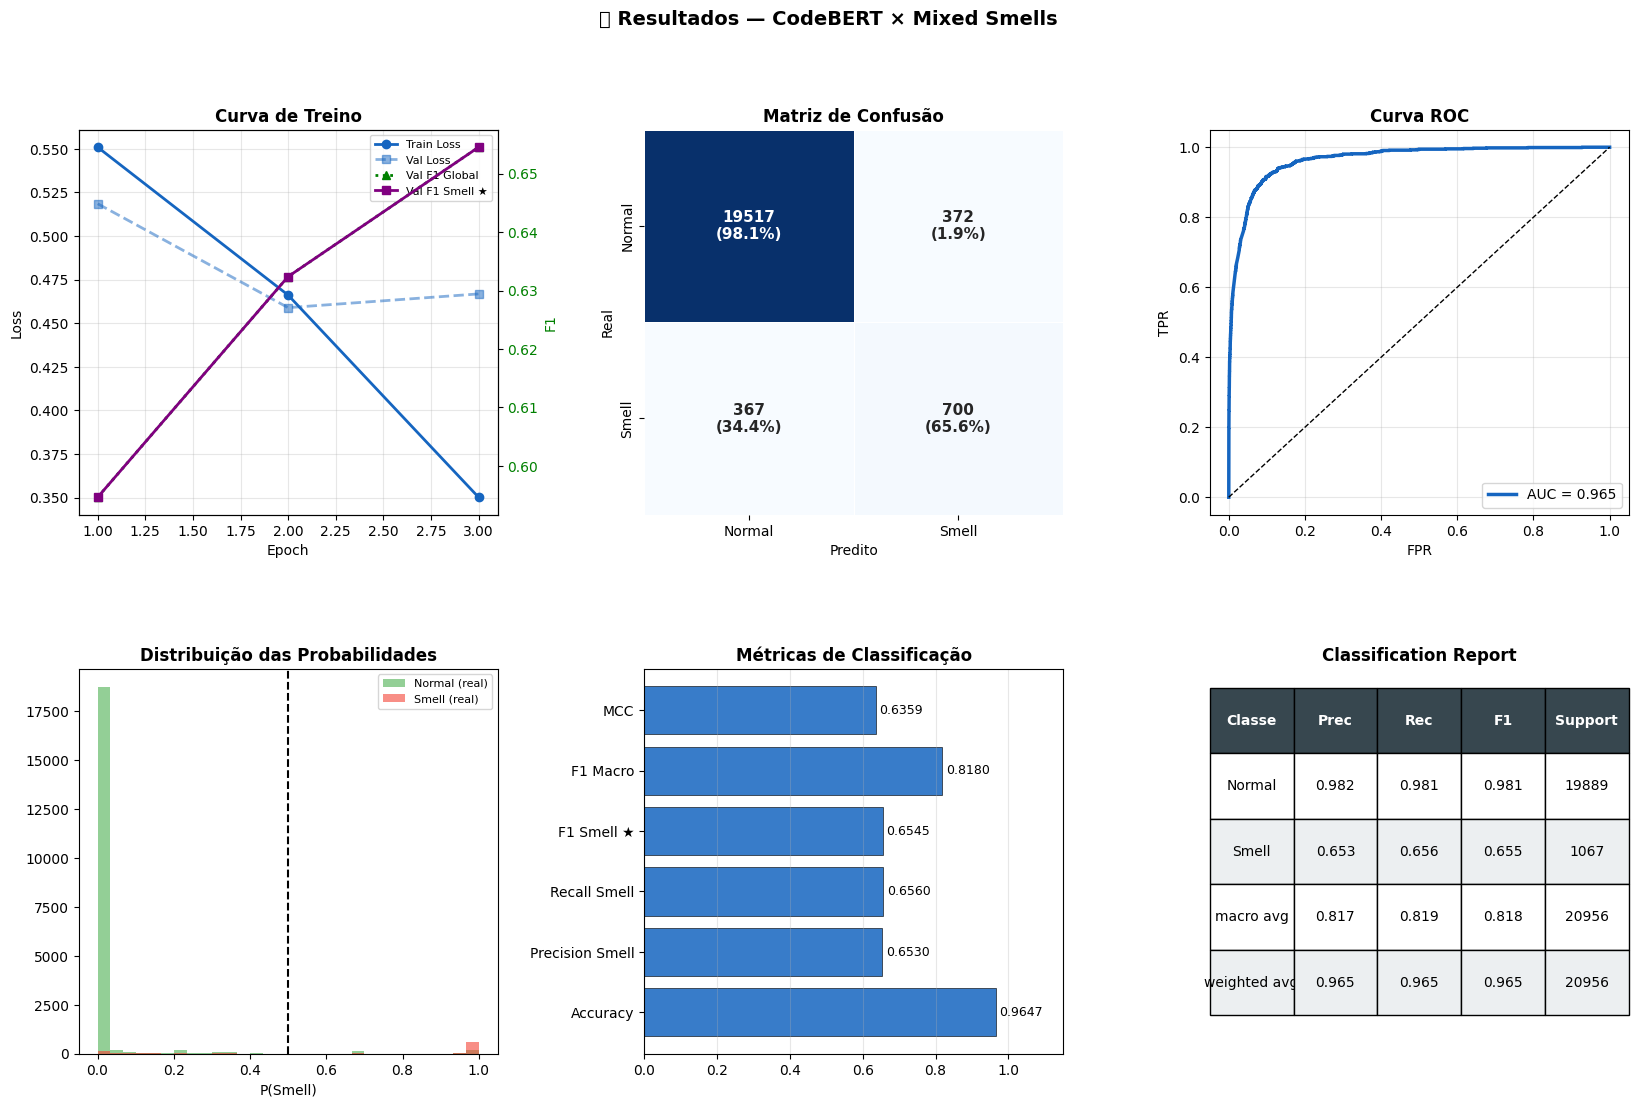

💾 Painel salvo em /kaggle/working/exp1_codebert_mixedsmells.png

📋 Classification Report completo — CodeBERT × Mixed Smells
              precision    recall  f1-score   support

  Normal (0)       0.98      0.98      0.98     19889
   Smell (1)       0.65      0.66      0.65      1067

    accuracy                           0.96     20956
   macro avg       0.82      0.82      0.82     20956
weighted avg       0.96      0.96      0.96     20956



In [13]:
lbl_cb_mixed, pred_cb_mixed, prob_cb_mixed = evaluate_model(model_cb_mixed, test_dl)

metrics_cb_mixed = plot_experiment(
    history    = hist_cb_mixed,
    y_true     = lbl_cb_mixed,
    y_pred     = pred_cb_mixed,
    y_prob     = prob_cb_mixed,
    exp_label  = 'CodeBERT × Mixed Smells',
    color      = EXP_COLORS['CodeBERT × Mixed Smells'],
    save_path  = f"{CONFIG['output_dir']}exp1_codebert_mixedsmells.png",
)

print('\n📋 Classification Report completo — CodeBERT × Mixed Smells')
print(classification_report(lbl_cb_mixed, pred_cb_mixed, target_names=['Normal (0)','Smell (1)']))


---
## 7. Resultados Finais


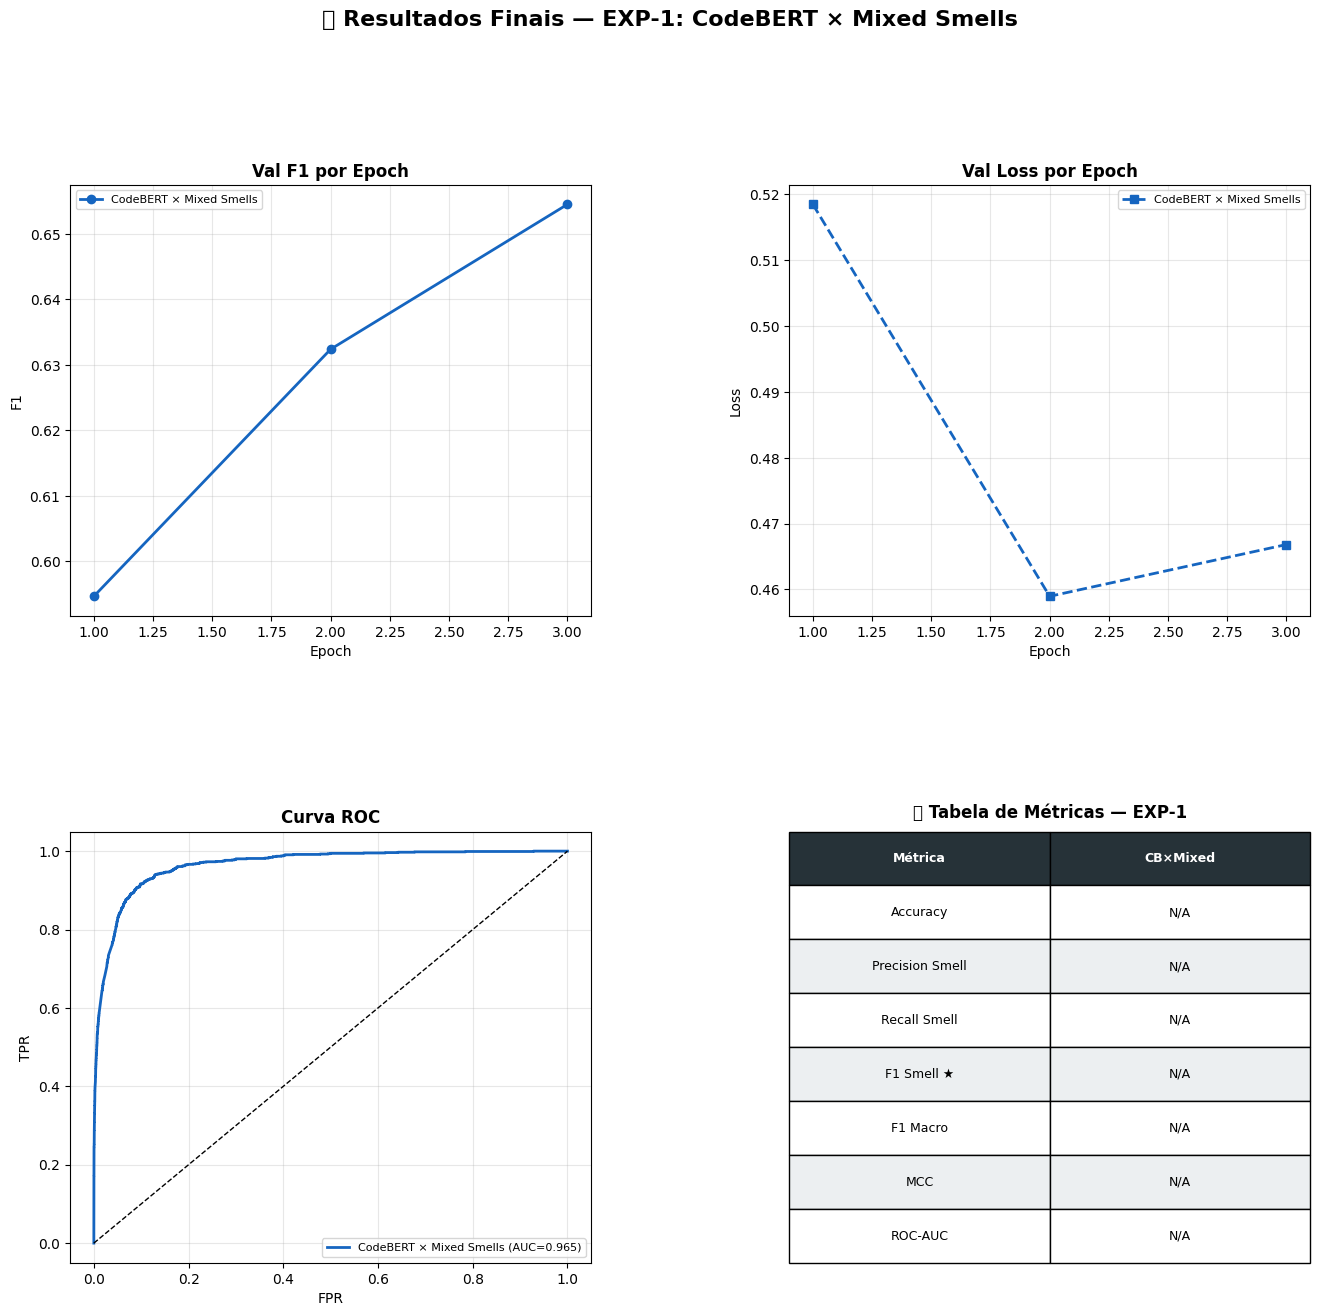

✅ Resultados finais salvos!


In [14]:
# ── Dados para o painel de resultados ──────────────────────────
EXPERIMENTS = {
    'CodeBERT × Mixed Smells' : (metrics_cb_mixed, hist_cb_mixed, lbl_cb_mixed, pred_cb_mixed, prob_cb_mixed),
}

fig = plt.figure(figsize=(16, 14))
fig.suptitle('🏆 Resultados Finais — EXP-1: CodeBERT × Mixed Smells', fontsize=16, fontweight='bold', y=1.005)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.50, wspace=0.38)

# ── Linha 1: Curva de Treino (F1 por epoch) ─────────────────
ax_train = fig.add_subplot(gs[0, 0])
for exp, (_, hist, *_) in EXPERIMENTS.items():
    epochs = range(1, len(hist['val_f1']) + 1)
    ax_train.plot(epochs, hist['val_f1'], 'o-', color=EXP_COLORS[exp],
                  linewidth=2, label=exp)
ax_train.set_title('Val F1 por Epoch', fontweight='bold')
ax_train.set_xlabel('Epoch'); ax_train.set_ylabel('F1')
ax_train.legend(fontsize=8); ax_train.grid(True, alpha=0.3)

# ── Linha 1: Val Loss ─────────────────────────────────────────
ax_loss = fig.add_subplot(gs[0, 1])
for exp, (_, hist, *_) in EXPERIMENTS.items():
    epochs = range(1, len(hist['val_loss']) + 1)
    ax_loss.plot(epochs, hist['val_loss'], 's--', color=EXP_COLORS[exp],
                 linewidth=2, label=exp)
ax_loss.set_title('Val Loss por Epoch', fontweight='bold')
ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
ax_loss.legend(fontsize=8); ax_loss.grid(True, alpha=0.3)

# ── Linha 2: Curva ROC ───────────────────────────────────────
ax_roc = fig.add_subplot(gs[1, 0])
for exp, (_, _, y_true, _, y_prob) in EXPERIMENTS.items():
    try:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_val     = roc_auc_score(y_true, y_prob)
        ax_roc.plot(fpr, tpr, color=EXP_COLORS[exp], linewidth=2,
                    label=f'{exp} (AUC={auc_val:.3f})')
    except Exception:
        pass
ax_roc.plot([0,1],[0,1],'k--', linewidth=1)
ax_roc.set_title('Curva ROC', fontweight='bold')
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.legend(fontsize=8); ax_roc.grid(True, alpha=0.3)

# ── Tabela resumo final ───────────────────────────────────────
ax_tbl = fig.add_subplot(gs[1, 1])
ax_tbl.axis('off')

met_keys = ['accuracy','precision_smell','recall_smell','f1_smell','f1_macro','mcc','roc_auc']
met_lbls = ['Accuracy','Precision Smell','Recall Smell','F1 Smell ★','F1 Macro','MCC','ROC-AUC']

col_labels = ['Métrica', 'CB×Mixed']
exp_order  = list(EXPERIMENTS.keys())

table_rows = []
for lbl, key in zip(met_lbls, met_keys):
    vals   = [EXPERIMENTS[e][0].get(key, float('nan')) for e in exp_order]
    row    = [lbl] + [f'{v:.4f}' if not float('nan') != float('nan') and not (v != v) else 'N/A' for v in vals]
    table_rows.append(row)

tbl = ax_tbl.table(
    cellText  = table_rows,
    colLabels = col_labels,
    cellLoc   = 'center',
    loc       = 'center',
    bbox      = [0.0, 0.0, 1.0, 1.0],
)
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#263238')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#ECEFF1')
ax_tbl.set_title('📋 Tabela de Métricas — EXP-1', fontweight='bold', pad=10)

plt.savefig(f"{CONFIG['output_dir']}resultados_finais.png", dpi=150, bbox_inches='tight')
plt.show()
print('✅ Resultados finais salvos!')


In [15]:
# ── Resumo em texto no console ────────────────────────────────
met_keys = ['accuracy','precision_smell','recall_smell','f1_smell','f1_macro','mcc','roc_auc']
met_lbls = ['Accuracy','Precision Smell','Recall Smell','F1 Smell ★','F1 Macro','MCC','ROC-AUC']

print('\n' + '═'*50)
print(f'  {"RESUMO FINAL — EXP-1: CB × Mixed Smells":^46}')
print('═'*50)
print(f'  {"Métrica":<20} {"CB×Mixed":>9}')
print('─'*50)
for lbl, key in zip(met_lbls, met_keys):
    v = metrics_cb_mixed.get(key, float('nan'))
    val_str = f'{v:>8.4f}' if v == v else f'{'N/A':>8}'
    print(f'  {lbl:<20} {val_str}')
print('═'*50)
print('  CB=CodeBERT  Mixed=Mixed Smells (todos os tipos)')



══════════════════════════════════════════════════
     RESUMO FINAL — EXP-1: CB × Mixed Smells    
══════════════════════════════════════════════════
  Métrica               CB×Mixed
──────────────────────────────────────────────────
  Accuracy               0.9647
  Precision Smell        0.6530
  Recall Smell           0.6560
  F1 Smell ★             0.6545
  F1 Macro               0.8180
  MCC                    0.6359
  ROC-AUC                0.9651
══════════════════════════════════════════════════
  CB=CodeBERT  Mixed=Mixed Smells (todos os tipos)


## 8. Salvamento dos Modelos e Resultados


In [ ]:
save_map = {
    'codebert_mixedsmells' : (model_cb_mixed, tok_cb),
}

for folder_name, (model, tokenizer) in save_map.items():
    save_path = f"{CONFIG['output_dir']}{folder_name}"
    unwrap(model).save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)
    print(f'  💾 Salvo: {save_path}')

# JSON com todas as métricas
all_results = {}
for exp, (metrics, _, *_) in EXPERIMENTS.items():
    all_results[exp] = {k: round(float(v), 6) for k, v in metrics.items()}
all_results['config'] = {k: str(v) for k, v in CONFIG.items()}

json_path = f"{CONFIG['output_dir']}all_results.json"
with open(json_path, 'w') as f:
    json.dump(all_results, f, indent=2)

print(f'\n  📄 Métricas JSON: {json_path}')
print('\n✅ Tudo salvo com sucesso!')


  💾 Salvo: /kaggle/working/codebert_mixedsmells

  📄 Métricas JSON: /kaggle/working/all_results.json

✅ Tudo salvo com sucesso!
